# Asteroid Family Identification via Hierarchical Clustering Method (HCM)

Implementation of Zappalà et al. 1990 — *Asteroid Families I: Identification by Hierarchical Clustering and Reliability Assessment*

**Method**: Single-linkage hierarchical clustering in proper orbital element space, using a physically motivated velocity-space distance metric (Eq. 2 of the paper).

**Benchmark**: AstDys family catalog (Milani group). Goal: identify ≥8 families at ≥95% completeness.

## 1. Imports and Configuration

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from mpl_toolkits.mplot3d import Axes3D
from scipy.cluster.hierarchy import linkage, fcluster

%matplotlib widget

# ---------------------------------------------------------------------------
# Zone boundaries from Table I, Zappalà et al. 1990
# Zones are delimited by Jupiter mean-motion resonances.
# Zones 1 and 8 are excluded: too sparse / dynamically complex.
# ---------------------------------------------------------------------------
ZONE_BOUNDARIES = {
    2: (2.065, 2.3),
    3: (2.3,   2.501),
    4: (2.501, 2.825),
    5: (2.825, 2.958),
    6: (2.958, 3.030),
    7: (3.030, 3.278),
}

# ---------------------------------------------------------------------------
# Per-zone velocity cutoffs (m/s) for dendrogram cutting.
# Determined empirically by sweeping cutoffs and finding the threshold
# just before single-linkage chaining begins in each zone.
# The paper's original values (120-160 m/s) were calibrated for 4,100
# asteroids; our denser dataset requires tighter cutoffs.
# ---------------------------------------------------------------------------
ZONE_CUTOFFS = {
    2: 60,
    3: 60,
    4: 80,
    5: 80,
    6: 80,
    7: 120,
}

# ---------------------------------------------------------------------------
# Target families — AstDys family IDs and names
# ---------------------------------------------------------------------------
FAMILY_NAMES = {
    4:    'Vesta',
    15:   'Eunomia',
    20:   'Massalia',
    24:   'Themis',
    158:  'Koronis',
    170:  'Maria',
    221:  'Eos',
    490:  'Veritas',
    847:  'Agnia',
    1040: 'Natasha',
}

## 2. Load Data

In [9]:
# proper_asteroid_data.csv  : proper orbital elements (a, e, sin_i, ...)
# family_membership.csv     : AstDys family assignments (name, family1, ...)
proper   = pd.read_csv('proper_asteroid_data_clean.csv')
families = pd.read_csv('family_membership.csv')

df = proper.merge(families[['name', 'family1']], on='name', how='left')
df['family1'] = df['family1'].fillna(0).astype(int)

print(f"Total asteroids loaded: {len(df):,}")
print(f"Asteroids with family assignment: {(df['family1'] > 0).sum():,}")
print()

# Count members per target family
print("Target family sizes in dataset:")
for fid, fname in FAMILY_NAMES.items():
    n = (df['family1'] == fid).sum()
    print(f"  {fname:12s} (id={fid:4d}): {n:,}")

/tmp/ipykernel_117743/988242616.py:3: DtypeWarning: Columns (0: name) have mixed types. Specify dtype option on import or set low_memory=False.
  proper   = pd.read_csv('proper_asteroid_data_clean.csv')
/tmp/ipykernel_117743/988242616.py:4: DtypeWarning: Columns (0: name, 1: near1) have mixed types. Specify dtype option on import or set low_memory=False.
  families = pd.read_csv('family_membership.csv')


Total asteroids loaded: 1,152,208
Asteroids with family assignment: 248,507

Target family sizes in dataset:
  Vesta        (id=   4): 16,447
  Eunomia      (id=  15): 20,216
  Massalia     (id=  20): 14,324
  Themis       (id=  24): 9,887
  Koronis      (id= 158): 13,240
  Maria        (id= 170): 6,594
  Eos          (id= 221): 34,884
  Veritas      (id= 490): 6,197
  Agnia        (id= 847): 7,099
  Natasha      (id=1040): 5,543


## 3. Visualise Known Families

In [10]:
def plot_family(family_id, df=df, family_names=FAMILY_NAMES):
    """
    Plot a known family in all three proper-element planes:
    (a, e), (a, sin_i), (e, sin_i).
    Red = family members, grey = background.
    """
    name    = family_names.get(family_id, f'Family {family_id}')
    members = df[df['family1'] == family_id]
    bg      = df[df['family1'] != family_id]
    print(f"{name}: {len(members):,} members in dataset")

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    for ax, (xcol, ycol) in zip(axes, [('a','e'), ('a','sin_i'), ('e','sin_i')]):
        ax.scatter(bg[xcol],      bg[ycol],      s=1, c='lightgray', alpha=0.3, label='background')
        ax.scatter(members[xcol], members[ycol], s=8, c='red',       alpha=0.7,
                   label=f'{name} (n={len(members):,})')
        ax.set_xlabel(xcol); ax.set_ylabel(ycol)
        ax.set_title(f'{name} — {xcol} vs {ycol}')
        ax.set_xlim(members[xcol].min()-0.1, members[xcol].max()+0.1)
        ax.set_ylim(members[ycol].min()-0.1, members[ycol].max()+0.1)
        ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(f'{name.lower()}_ground_truth.png', dpi=150)
    plt.show()


def plot_family_3d(family_id, df=df, family_names=FAMILY_NAMES):
    """3D scatter of a family in (a, e, sin_i) space."""
    name    = family_names.get(family_id, f'Family {family_id}')
    members = df[df['family1'] == family_id]
    bg      = df[df['family1'] != family_id]
    print(f"{name}: {len(members):,} members in dataset")

    fig = plt.figure(figsize=(8, 6))
    ax  = fig.add_subplot(111, projection='3d')
    ax.scatter(bg['a'],      bg['e'],      bg['sin_i'],      s=1, c='lightgray', alpha=0.2, label='background')
    ax.scatter(members['a'], members['e'], members['sin_i'], s=8, c='red',       alpha=0.7,
               label=f'{name} (n={len(members):,})')
    ax.set_xlabel('a (AU)'); ax.set_ylabel('e'); ax.set_zlabel('sin i')
    ax.set_title(f'{name} — 3D proper element space')
    ax.legend()
    plt.tight_layout()
    plt.show()


# Example — uncomment to plot:
# plot_family(158)      # Koronis
# plot_family_3d(24)    # Themis

## 4. HCM Core Functions

### Distance metric (Zappalà et al. 1990, Eq. 2)

$$\delta v = n a' \sqrt{k_1 \left(\frac{\delta a'}{a'}\right)^2 + k_2 (\delta e')^2 + k_3 (\delta \sin i')^2}$$

with $k_1 = 5/4$, $k_2 = 2$, $k_3 = 2$ (standard metric coefficients, Section II of the paper).

$na'$ is the circular orbital velocity at $a'$. Units: AU/yr × 4740.9 = m/s.

In [11]:
# Metric coefficients — Zappalà et al. 1990, Section II
K1, K2, K3 = 5/4, 2, 2

# 1 AU/yr in m/s: (1.496e11 m) / (3.156e7 s) = 4740.9 m/s
AU_YR_TO_MS = 4740.9


def compute_distances(X, chunk_size=1000, verbose=True):
    """
    Compute all N*(N-1)/2 pairwise delta_v distances (Eq. 2) in row chunks
    to avoid allocating an N^2 array all at once.

    For each row i, we vectorise over all j > i simultaneously using numpy,
    so the inner loop is a numpy operation, not a Python loop per pair.
    Peak memory ~ chunk_size * N * 4 bytes (float32).

    Parameters
    ----------
    X          : array (N, 3) — columns [a', e', sin_i']
    chunk_size : rows processed per outer iteration (1000 → ~few hundred MB)

    Returns
    -------
    dist : condensed distance array, length N*(N-1)/2, dtype float32
           Compatible with scipy.cluster.hierarchy.linkage.
    """
    N       = len(X)
    n_pairs = N * (N - 1) // 2
    dist    = np.empty(n_pairs, dtype=np.float32)

    a, e, si = X[:, 0], X[:, 1], X[:, 2]
    pair_idx = 0

    for i_start in range(0, N, chunk_size):
        i_end = min(i_start + chunk_size, N)

        if verbose and i_start % (chunk_size * 20) == 0:
            print(f"    {100*pair_idx/n_pairs:.1f}%  "
                  f"({pair_idx:,} / {n_pairs:,} pairs)", flush=True)

        for i in range(i_start, i_end):
            j = i + 1
            if j >= N:
                continue

            # All pairs (i, j), (i, j+1), ..., (i, N-1) at once
            a0  = (a[i] + a[j:]) / 2.0
            n0  = 2.0 * np.pi / (a0 ** 1.5)   # Kepler: n = 2π / T = 2π / a^1.5
            da  = a[i] - a[j:]
            de  = e[i] - e[j:]
            dsi = si[i] - si[j:]

            dv = n0 * a0 * np.sqrt(
                K1 * (da / a0)**2 +
                K2 * de**2 +
                K3 * dsi**2
            ) * AU_YR_TO_MS

            n_new = len(dv)
            dist[pair_idx : pair_idx + n_new] = dv
            pair_idx += n_new

    return dist


def run_hcm_zone(df, zone, save=True, chunk_size=1000):
    """
    Run HCM on one zone of the asteroid belt.

    Steps:
      1. Filter df to the zone's semimajor axis range.
      2. Compute all pairwise delta_v distances.
      3. Build single-linkage dendrogram (scipy 'single' method).
         Single linkage means: distance(group A, group B) = min pairwise distance.
         This is exactly the update rule in step (3) of the paper.
      4. Cut dendrogram at ZONE_CUTOFFS[zone] to produce family labels.
      5. Return all groups with >= min_members members.

    Saves Z_zone{zone}.npy and zone{zone}_df.csv so you can re-cut
    at different thresholds later without recomputing (use recut_zone).

    Returns
    -------
    families : list of lists of asteroid name strings
    zone_df  : DataFrame for this zone with 'hcm_label' column added
    """
    a_min, a_max  = ZONE_BOUNDARIES[zone]
    cutoff        = ZONE_CUTOFFS[zone]

    zone_df = df[
        (df['a'] >= a_min) & (df['a'] < a_max)
    ].dropna(subset=['a', 'e', 'sin_i']).copy()

    n       = len(zone_df)
    n_pairs = n * (n - 1) // 2
    mem_mb  = n_pairs * 4 / 1e6
    print(f"Zone {zone} ({a_min}–{a_max} AU): {n:,} asteroids | "
          f"{n_pairs:,} pairs | ~{mem_mb:.0f} MB")

    X = zone_df[['a', 'e', 'sin_i']].values

    print(f"  Computing pairwise distances...")
    dist = compute_distances(X, chunk_size=chunk_size)

    print(f"  Building dendrogram (single linkage)...")
    Z = linkage(dist, method='single')

    if save:
        np.save(f'Z_zone{zone}.npy', Z)
        zone_df.to_csv(f'zone{zone}_df.csv', index=False)
        print(f"  Saved Z_zone{zone}.npy + zone{zone}_df.csv")

    labels  = fcluster(Z, t=cutoff, criterion='distance')
    zone_df = zone_df.copy()
    zone_df['hcm_label'] = labels

    families = _labels_to_families(zone_df)
    print(f"  → {len(families)} families at cutoff={cutoff} m/s")
    return families, zone_df


def recut_zone(zone, cutoff, min_members=5):
    """
    Re-cut a previously saved dendrogram at a new cutoff — runs instantly.
    Use this to experiment with cutoffs without recomputing distances.
    """
    Z       = np.load(f'Z_zone{zone}.npy')
    zone_df = pd.read_csv(f'zone{zone}_df.csv')
    labels  = fcluster(Z, t=cutoff, criterion='distance')
    zone_df['hcm_label'] = labels
    families = _labels_to_families(zone_df, min_members)
    largest  = len(families[0]) if families else 0
    print(f"Zone {zone} @ {cutoff} m/s → {len(families)} families, largest={largest:,}")
    return families, zone_df


def _labels_to_families(zone_df, min_members=5):
    """Convert hcm_label column to sorted list of member-name lists."""
    families = []
    for lbl in np.unique(zone_df['hcm_label']):
        members = zone_df[zone_df['hcm_label'] == lbl]['name'].tolist()
        if len(members) >= min_members:
            families.append(members)
    families.sort(key=len, reverse=True)
    return families


def run_all_zones(df, min_members=5):
    """Run HCM across all zones and return all families."""
    all_families = []
    total_start  = time.time()

    for zone in ZONE_BOUNDARIES:
        t0   = time.time()
        fams, _ = run_hcm_zone(df, zone)
        all_families.extend(fams)
        print(f"  Zone {zone} done in {time.time()-t0:.1f}s\n")

    print(f"All zones done in {time.time()-total_start:.1f}s")
    print(f"Total: {len(all_families):,} families, "
          f"{sum(len(f) for f in all_families):,} asteroids assigned")
    return all_families


def recut_all_zones(cutoffs=ZONE_CUTOFFS, min_members=5):
    """
    Re-cut all saved dendrograms using the given cutoff dict.
    Runs in seconds — no distance recomputation needed.
    """
    all_families = []
    for zone, cutoff in cutoffs.items():
        fams, _ = recut_zone(zone, cutoff, min_members)
        all_families.extend(fams)
    print(f"\nTotal: {len(all_families):,} families, "
          f"{sum(len(f) for f in all_families):,} asteroids assigned")
    return all_families

## 5. Run HCM

**First run** (no saved Z files): call `run_all_zones` — computes distances + dendrograms for all zones and saves them to disk.

**Subsequent runs** (Z files already saved): call `recut_all_zones` — loads saved dendrograms and re-cuts instantly.

In [12]:
import os

# Check whether saved Z files exist for all zones
zones_missing = [z for z in ZONE_BOUNDARIES if not os.path.exists(f'Z_zone{z}.npy')]

if zones_missing:
    print(f"No saved dendrograms found for zones {zones_missing}.")
    print("Running full HCM — this may take several minutes...\n")
    all_families = run_all_zones(df)
else:
    print("Saved dendrograms found for all zones. Re-cutting from disk...\n")
    all_families = recut_all_zones()

Saved dendrograms found for all zones. Re-cutting from disk...



/tmp/ipykernel_117743/2759668535.py:128: DtypeWarning: Columns (0: name) have mixed types. Specify dtype option on import or set low_memory=False.
  zone_df = pd.read_csv(f'zone{zone}_df.csv')


Zone 2 @ 60 m/s → 1012 families, largest=74,989
Zone 3 @ 60 m/s → 301 families, largest=41,793
Zone 4 @ 80 m/s → 59 families, largest=20,379
Zone 5 @ 80 m/s → 452 families, largest=16,524
Zone 6 @ 80 m/s → 293 families, largest=52,379
Zone 7 @ 120 m/s → 260 families, largest=32,184

Total: 2,377 families, 407,049 asteroids assigned


## 6. Evaluate Against AstDys Ground Truth

In [13]:
def evaluate(all_families, df, family_names=FAMILY_NAMES, threshold=0.95):
    """
    Compare HCM output against AstDys ground truth.

    For each known family, find the HCM cluster that contains the most
    true members (voting). Report:
      - Completeness (recall)  = recovered / true_size
      - Precision              = recovered / found_size
      - F1                     = harmonic mean of completeness and precision

    A family 'passes' if completeness >= threshold.
    """
    # Map each asteroid name to the index of its HCM family
    name_to_fi = {}
    for i, fam in enumerate(all_families):
        for name in fam:
            name_to_fi[name] = i

    rows = []
    for fam_id, fam_name in family_names.items():
        true_members = set(df[df['family1'] == fam_id]['name'].tolist())
        if not true_members:
            print(f"  {fam_name}: no members in dataset, skipping")
            continue

        # Vote: which HCM family received the most true members?
        vote = {}
        for name in true_members:
            if name in name_to_fi:
                fi = name_to_fi[name]
                vote[fi] = vote.get(fi, 0) + 1

        if not vote:
            completeness = precision = f1 = 0.0
            recovered = found_size = 0
        else:
            best_fi      = max(vote, key=vote.get)
            recovered    = vote[best_fi]
            found_size   = len(all_families[best_fi])
            completeness = recovered / len(true_members)
            precision    = recovered / found_size
            f1           = (2 * precision * completeness /
                            (precision + completeness)
                            if (precision + completeness) > 0 else 0.0)

        rows.append({
            'family':       fam_name,
            'true_size':    len(true_members),
            'recovered':    recovered,
            'found_size':   found_size,
            'completeness': round(completeness * 100, 1),
            'precision':    round(precision    * 100, 1),
            'f1':           round(f1           * 100, 1),
            'pass':         '✓' if completeness >= threshold else '✗',
        })

    results = pd.DataFrame(rows).sort_values('completeness', ascending=False)

    print(f"  {'Family':12} {'True':>6} {'Recov':>6} {'Found':>7} "
          f"{'Compl':>7} {'Prec':>7} {'F1':>7}  Pass")
    print("-" * 70)
    for _, r in results.iterrows():
        print(f"  {r['family']:12} {r['true_size']:>6,} {r['recovered']:>6,} "
              f"{r['found_size']:>7,} {r['completeness']:>6.1f}% "
              f"{r['precision']:>6.1f}% {r['f1']:>6.1f}%  {r['pass']}")

    n_pass = results['pass'].eq('✓').sum()
    print(f"\n{n_pass}/{len(results)} families reach {int(threshold*100)}% completeness")
    return results


results = evaluate(all_families, df)

  Family         True  Recov   Found   Compl    Prec      F1  Pass
----------------------------------------------------------------------
  Natasha       5,543  3,042   6,928   54.9%   43.9%   48.8%  ✗
  Veritas       6,197  2,986  32,184   48.2%    9.3%   15.6%  ✗
  Eunomia      20,216  8,262  20,379   40.9%   40.5%   40.7%  ✗
  Maria         6,594  2,635   6,670   40.0%   39.5%   39.7%  ✗
  Massalia     14,324  5,626  41,793   39.3%   13.5%   20.1%  ✗
  Agnia         7,099  2,763   7,273   38.9%   38.0%   38.4%  ✗
  Themis        9,887  3,765  10,521   38.1%   35.8%   36.9%  ✗
  Koronis      13,240  4,123  16,524   31.1%   25.0%   27.7%  ✗
  Eos          34,884  7,454  32,184   21.4%   23.2%   22.2%  ✗
  Vesta        16,447  3,368  15,233   20.5%   22.1%   21.3%  ✗

0/10 families reach 95% completeness


In [15]:
def sweep_with_truth(zone, cutoffs, df, family_names, min_members=5):
    """
    Sweep cutoffs for a zone and show recovery of known families at each level.
    Much more informative than just looking at cluster sizes.
    """
    Z       = np.load(f'Z_zone{zone}.npy')
    zone_df = pd.read_csv(f'zone{zone}_df.csv')

    # Which known families live in this zone?
    a_min, a_max = ZONE_BOUNDARIES[zone]
    zone_family_ids = []
    for fam_id, fam_name in family_names.items():
        members_in_zone = df[
            (df['family1'] == fam_id) &
            (df['a'] >= a_min) & (df['a'] < a_max)
        ]
        if len(members_in_zone) > 0:
            zone_family_ids.append((fam_id, fam_name, len(members_in_zone)))

    if not zone_family_ids:
        print(f"Zone {zone}: no known families")
        return

    print(f"\nZone {zone} ({a_min}–{a_max} AU)")
    print(f"Known families in this zone: "
          f"{', '.join(f'{n}({c})' for _,n,c in zone_family_ids)}")
    print()

    # Header
    header = f"{'Cutoff':>8} {'Largest':>8}"
    for _, fname, ftrue in zone_family_ids:
        header += f"  {fname[:8]:>10}({ftrue})"
    print(header)
    print("-" * len(header))

    for c in cutoffs:
        labels = fcluster(Z, t=c, criterion='distance')
        zone_df['hcm_label'] = labels

        # For each known family, find best matching cluster
        row = f"{c:>8} "

        # largest cluster size
        _, counts = np.unique(labels, return_counts=True)
        row += f"{counts.max():>8}"

        for fam_id, fname, ftrue in zone_family_ids:
            # merge ground truth into zone_df
            true_names = set(df[df['family1'] == fam_id]['name'].tolist())

            # vote for best cluster
            vote = {}
            for name in true_names:
                match = zone_df[zone_df['name'] == name]
                if len(match) > 0:
                    lbl = match['hcm_label'].iloc[0]
                    vote[lbl] = vote.get(lbl, 0) + 1

            if vote:
                best_lbl     = max(vote, key=vote.get)
                recovered    = vote[best_lbl]
                cluster_size = (zone_df['hcm_label'] == best_lbl).sum()
                pct          = recovered / ftrue * 100
                row += f"  {recovered:>4}/{ftrue:<4} {pct:>4.0f}% (sz={cluster_size})"
            else:
                row += f"  {'—':>14}"

        print(row)

In [ ]:
# In your local notebook, sweep all zones with the new Z files
for zone in [2, 3, 4, 5, 6, 7]:
    print()
    sweep_with_truth(zone, [10, 20, 30, 40, 50, 60, 80, 100, 120, 160], df, FAMILY_NAMES)



Zone 2 (2.065–2.3 AU)
Known families in this zone: Vesta(2330)

  Cutoff  Largest       Vesta(2330)
-----------------------------------


/tmp/ipykernel_117743/883066238.py:7: DtypeWarning: Columns (0: name) have mixed types. Specify dtype option on import or set low_memory=False.
  zone_df = pd.read_csv(f'zone{zone}_df.csv')


      10       86     4/2330    0% (sz=4)
      20       87    50/2330    2% (sz=53)
      30     2590  1818/2330   78% (sz=2590)
      40    13626  2295/2330   98% (sz=7420)
      50    56246  2300/2330   99% (sz=56246)


In [ ]:
for zone in [2, 3, 4, 5, 6, 7]:
    zone_df = pd.read_csv(f'zone{zone}_df.csv')
    n_fam = (zone_df['family1'] > 0).sum()
    n_bg  = (zone_df['family1'] == 0).sum()
    print(f"Zone {zone}: {len(zone_df):,} total | "
          f"{n_fam:,} family ({100*n_fam/len(zone_df):.1f}%) | "
          f"{n_bg:,} background")

## 7. Visualise HCM Results vs Ground Truth

Vesta: AstDys=16,447  HCM=15,233  completeness=20.5%  precision=22.1%


/tmp/ipykernel_117743/1812501438.py:55: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/tmp/ipykernel_117743/1812501438.py:56: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(f'{name.lower()}_hcm_vs_truth.png', dpi=150, bbox_inches='tight')
/home/zaraius/Documents/scicomp/scicomp-p2-zaraius-asteriod-families/venv/lib/python3.12/site-packages/ipympl/backend_nbagg.py:392: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  self.figure.savefig(buf, format='png', dpi='figure')


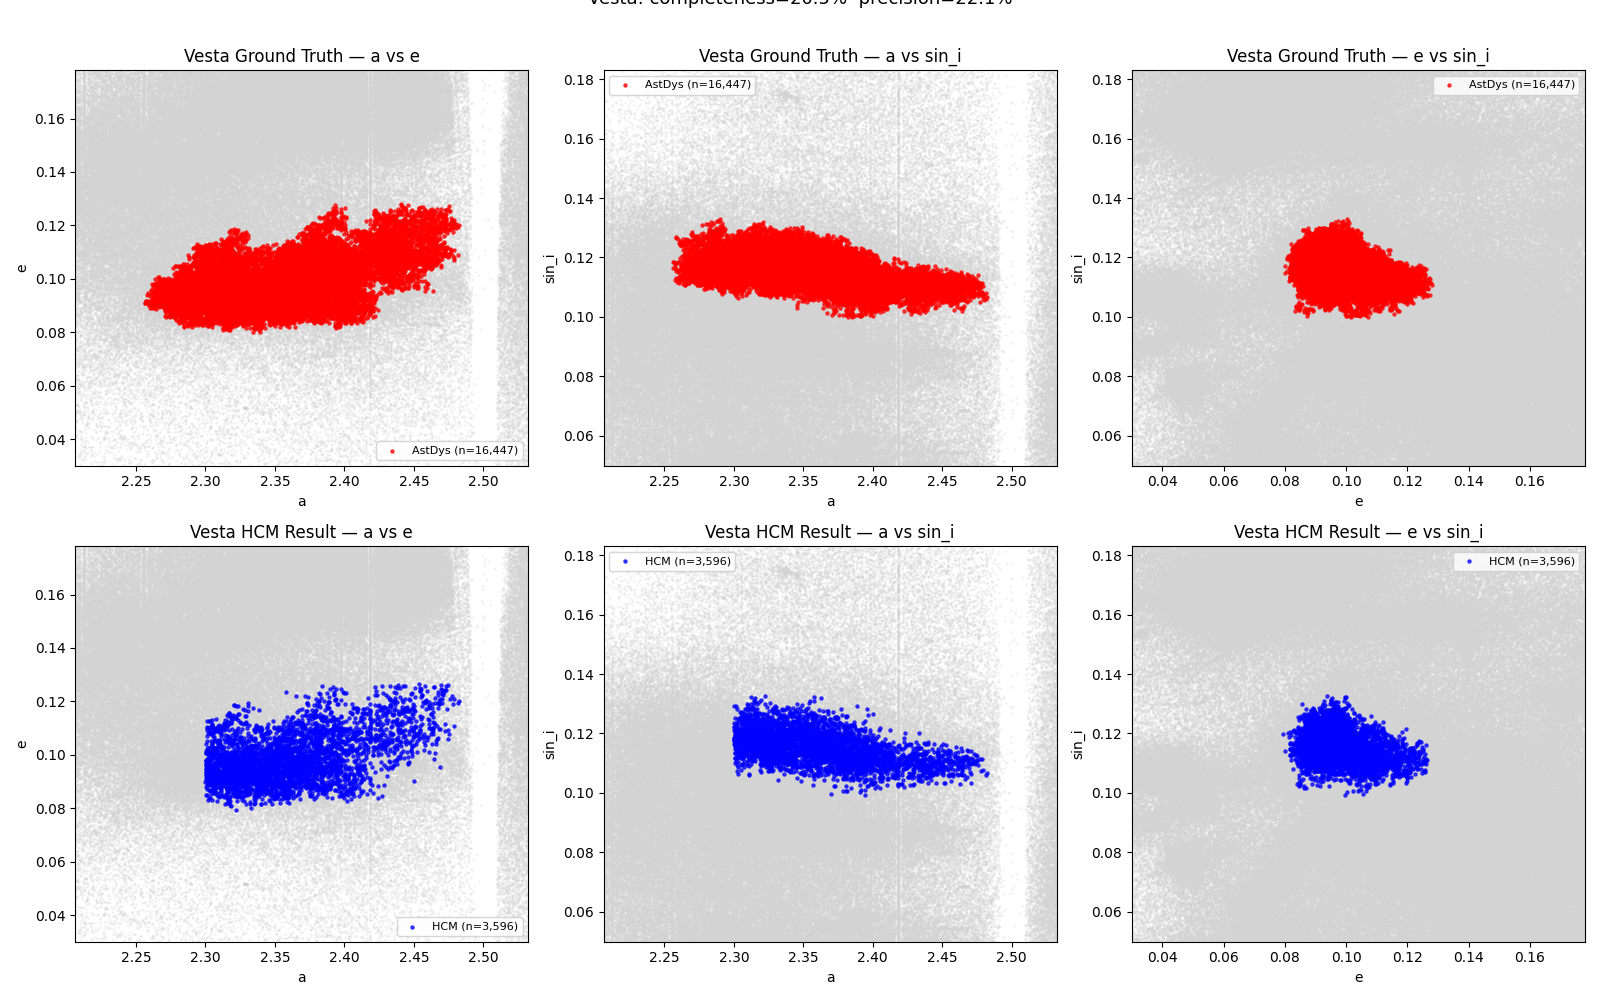

Eunomia: AstDys=20,216  HCM=20,379  completeness=40.9%  precision=40.5%


KeyboardInterrupt: 

In [14]:
def plot_hcm_vs_truth(family_id, all_families, df,
                      family_names=FAMILY_NAMES):
    """
    Side-by-side comparison: AstDys ground truth (top row) vs
    best-matching HCM cluster (bottom row) in all three element planes.
    """
    name         = family_names.get(family_id, f'Family {family_id}')
    true_members = df[df['family1'] == family_id]
    true_set     = set(true_members['name'].tolist())

    # Find the best-matching HCM family by vote
    name_to_fi = {}
    for i, fam in enumerate(all_families):
        for n_ in fam:
            name_to_fi[n_] = i
    vote = {}
    for n_ in true_set:
        if n_ in name_to_fi:
            fi = name_to_fi[n_]
            vote[fi] = vote.get(fi, 0) + 1
    if not vote:
        print(f"{name}: no HCM match found")
        return
    best_fi     = max(vote, key=vote.get)
    hcm_names   = set(all_families[best_fi])
    hcm_members = df[df['name'].isin(hcm_names)]

    recovered   = len(true_set & hcm_names)
    completeness = recovered / len(true_set) * 100
    precision    = recovered / len(hcm_names) * 100
    print(f"{name}: AstDys={len(true_set):,}  HCM={len(hcm_names):,}  "
          f"completeness={completeness:.1f}%  precision={precision:.1f}%")

    plots = [('a','e'), ('a','sin_i'), ('e','sin_i')]
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))

    for col, (xcol, ycol) in enumerate(plots):
        xlim = (true_members[xcol].min()-0.05, true_members[xcol].max()+0.05)
        ylim = (true_members[ycol].min()-0.05, true_members[ycol].max()+0.05)

        for row, (data, color, label, title_prefix) in enumerate([
            (true_members, 'red',  f'AstDys (n={len(true_members):,})', 'Ground Truth'),
            (hcm_members,  'blue', f'HCM (n={len(hcm_members):,})',     'HCM Result'),
        ]):
            ax = axes[row, col]
            ax.scatter(df[xcol], df[ycol], s=1, c='lightgray', alpha=0.2)
            ax.scatter(data[xcol], data[ycol], s=5, c=color, alpha=0.7, label=label)
            ax.set_xlim(*xlim); ax.set_ylim(*ylim)
            ax.set_xlabel(xcol); ax.set_ylabel(ycol)
            ax.set_title(f'{name} {title_prefix} — {xcol} vs {ycol}')
            ax.legend(fontsize=8)

    plt.suptitle(f'{name}: completeness={completeness:.1f}%  precision={precision:.1f}%',
                 fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig(f'{name.lower()}_hcm_vs_truth.png', dpi=150, bbox_inches='tight')
    plt.show()


# Plot all target families
for fid in FAMILY_NAMES:
    plot_hcm_vs_truth(fid, all_families, df)